In [1]:
import os
os.chdir('/Users/nchaparla/Documents/Alzheimer-s-Disease-Progression--OASIS')

import tensorflow as tf
import pandas as pd
import numpy as np
print(f"TensorFlow: {tf.__version__}")
print(f"Working directory: {os.getcwd()}")

TensorFlow: 2.21.0
Working directory: /Users/nchaparla/Documents/Alzheimer-s-Disease-Progression--OASIS


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load OASIS-2 data
df = pd.read_excel('data/oasis_longitudinal.xlsx')

# Clean and prepare
df = df.dropna()
df['Group'] = df['Group'].map({'Demented': 1, 'Nondemented': 0})
df = df.dropna(subset=['Group'])  # removes Converted rows

# Features and target
X = df[['MMSE', 'nWBV', 'CDR']].values
y = df['Group'].astype(int).values

# Scale features — required for neural networks
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset shape: {X.shape}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Demented rate: {y.mean()*100:.1f}%")

Dataset shape: (317, 3)
Training set: 253 samples
Test set: 64 samples
Demented rate: 40.1%


In [3]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import time

# ── ANN Model ──
start_ann = time.time()

ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

ann_time = round(time.time() - start_ann, 3)

# Evaluate
loss, ann_acc = ann_model.evaluate(X_test, y_test, verbose=0)
ann_pred = (ann_model.predict(X_test) > 0.5).astype(int).flatten()

print(f"ANN Accuracy: {ann_acc*100:.2f}%")
print(f"ANN Training Time: {ann_time} seconds")
print(f"\nClassification Report:")
print(classification_report(y_test, ann_pred, 
      target_names=['Nondemented', 'Demented']))

/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
ANN Accuracy: 96.88%
ANN Training Time: 0.912 seconds

Classification Report:
              precision    recall  f1-score   support

 Nondemented       1.00      0.95      0.97        37
    Demented       0.93      1.00      0.96        27

    accuracy                           0.97        64
   macro avg       0.97      0.97      0.97        64
weighted avg       0.97      0.97      0.97        64



In [5]:
from tensorflow.keras.layers import SimpleRNN, Reshape

# ── RNN Model ──
start_rnn = time.time()

rnn_model = Sequential([
    Reshape((3, 1), input_shape=(3,)),  # RNN needs 3D input
    SimpleRNN(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

rnn_time = round(time.time() - start_rnn, 3)

# Evaluate
loss_rnn, rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)
rnn_pred = (rnn_model.predict(X_test) > 0.5).astype(int).flatten()

print(f"RNN Accuracy: {rnn_acc*100:.2f}%")
print(f"RNN Training Time: {rnn_time} seconds")
print(f"\nClassification Report:")
print(classification_report(y_test, rnn_pred,
      target_names=['Nondemented', 'Demented']))

/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
RNN Accuracy: 96.88%
RNN Training Time: 1.017 seconds

Classification Report:
              precision    recall  f1-score   support

 Nondemented       1.00      0.95      0.97        37
    Demented       0.93      1.00      0.96        27

    accuracy                           0.97        64
   macro avg       0.97      0.97      0.97        64
weighted avg       0.97      0.97      0.97        64



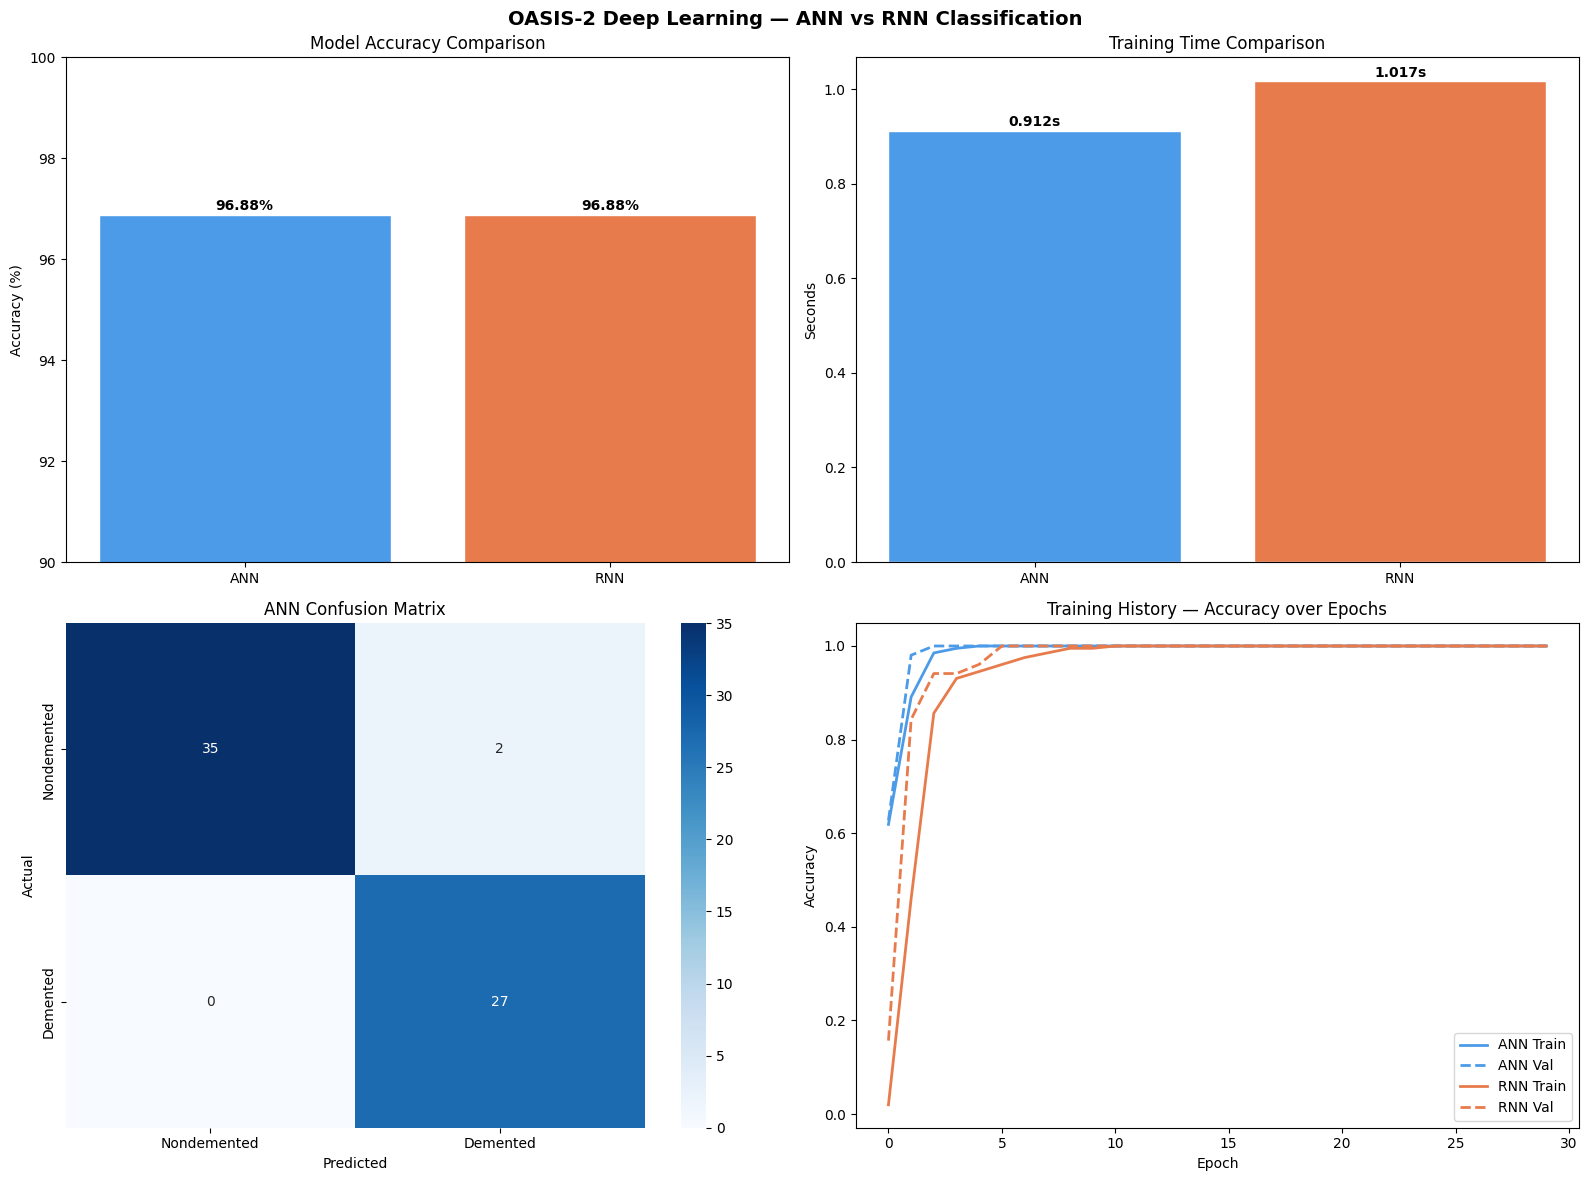

Saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('OASIS-2 Deep Learning — ANN vs RNN Classification', 
             fontsize=14, fontweight='bold')

# Chart 1 — Accuracy comparison
models_names = ['ANN', 'RNN']
accuracies = [ann_acc*100, rnn_acc*100]
axes[0,0].bar(models_names, accuracies, 
              color=['#4C9BE8', '#E87B4C'], edgecolor='white')
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy (%)')
axes[0,0].set_ylim(90, 100)
for i, v in enumerate(accuracies):
    axes[0,0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# Chart 2 — Training time comparison
times = [ann_time, rnn_time]
axes[0,1].bar(models_names, times,
              color=['#4C9BE8', '#E87B4C'], edgecolor='white')
axes[0,1].set_title('Training Time Comparison')
axes[0,1].set_ylabel('Seconds')
for i, v in enumerate(times):
    axes[0,1].text(i, v + 0.01, f'{v}s', ha='center', fontweight='bold')

# Chart 3 — ANN confusion matrix
cm_ann = confusion_matrix(y_test, ann_pred)
sns.heatmap(cm_ann, annot=True, fmt='d', ax=axes[1,0],
            cmap='Blues',
            xticklabels=['Nondemented', 'Demented'],
            yticklabels=['Nondemented', 'Demented'])
axes[1,0].set_title('ANN Confusion Matrix')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_xlabel('Predicted')

# Chart 4 — Training history (ANN vs RNN)
axes[1,1].plot(ann_history.history['accuracy'], 
               color='#4C9BE8', linewidth=2, label='ANN Train')
axes[1,1].plot(ann_history.history['val_accuracy'], 
               color='#4C9BE8', linewidth=2, linestyle='--', label='ANN Val')
axes[1,1].plot(rnn_history.history['accuracy'], 
               color='#E87B4C', linewidth=2, label='RNN Train')
axes[1,1].plot(rnn_history.history['val_accuracy'], 
               color='#E87B4C', linewidth=2, linestyle='--', label='RNN Val')
axes[1,1].set_title('Training History — Accuracy over Epochs')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()

plt.tight_layout()
save_path = '/Users/nchaparla/Documents/Alzheimer-s-Disease-Progression--OASIS/outputs/deep_learning_results.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")